In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
validation_df = pd.read_csv(
    "validation_fraud.csv"
)

day18_df = pd.read_csv(
    "day18_optimized_fraud_results.csv"
)

print("Validation dataset shape:", validation_df.shape)
print("Day 18 results shape:", day18_df.shape)

Validation dataset shape: (8648, 45)
Day 18 results shape: (8648, 13)


In [4]:
print("=" * 70)
print("VALIDATION DATASET COLUMNS")
print("=" * 70)

for i, col in enumerate(validation_df.columns):
    print(i, ":", col)

VALIDATION DATASET COLUMNS
0 : transaction_id
1 : transaction_date
2 : customer_id
3 : card_type
4 : amount
5 : merchant_category
6 : merchant_country
7 : transaction_channel
8 : device_type
9 : is_international
10 : is_card_present
11 : transactions_last_24h
12 : average_amount_30d
13 : risk_score
14 : is_fraud
15 : transaction_hour
16 : transaction_day
17 : transaction_month
18 : dataset_source
19 : sender_account_id
20 : receiver_account_id
21 : transaction_type
22 : sender_balance_before
23 : sender_balance_after
24 : receiver_balance_before
25 : receiver_balance_after
26 : customer_age_group
27 : customer_city
28 : kyc_level
29 : login_attempts
30 : account_age_days
31 : product_category
32 : payment_method
33 : billing_country
34 : shipping_country
35 : email_age_days
36 : ip_risk_level
37 : failed_payment_attempts
38 : delivery_speed
39 : customer_balance
40 : location
41 : distance_from_home_km
42 : transactions_last_1h
43 : new_device
44 : new_location


In [5]:
print("\nFirst 5 validation transactions:")
display(validation_df.head())


First 5 validation transactions:


,transaction_id,transaction_date,customer_id,card_type,amount,merchant_category,merchant_country,transaction_channel,device_type,is_international,is_card_present,transactions_last_24h,average_amount_30d,risk_score,is_fraud,transaction_hour,transaction_day,transaction_month,dataset_source,sender_account_id,receiver_account_id,transaction_type,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,customer_age_group,customer_city,kyc_level,login_attempts,account_age_days,product_category,payment_method,billing_country,shipping_country,email_age_days,ip_risk_level,failed_payment_attempts,delivery_speed,customer_balance,location,distance_from_home_km,transactions_last_1h,new_device,new_location
0,CC00002671,2025-10-05 14:13:49,C001521,amex,99.55,pharmacy,australia,pos,mac,0.0,0.0,2.0,215.23,36.0,0,14,5,10,Credit Card Fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FT00010351,2025-04-16 16:05:52,NaN,NaN,65.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,0,16,16,4,Financial Fraud,A0002599,A0006284,transfer,23983.62,23918.04,284790.04,284855.62,46-60,hyderabad,basic,3.0,339.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ORD00003994,2025-11-22 14:45:37,EC001526,NaN,170.18,NaN,NaN,NaN,windows,NaN,NaN,NaN,NaN,32.0,0,14,22,11,Fraud Detection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1221.0,electronics,wallet,canada,canada,776.0,medium,2.0,same_day,NaN,NaN,NaN,NaN,NaN,NaN
3,ORD00001858,2025-05-14 07:43:18,EC000638,NaN,132.03,NaN,NaN,NaN,mac,NaN,NaN,NaN,NaN,33.0,0,7,14,5,Fraud Detection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.0,beauty,credit_card,india,india,1561.0,low,3.0,standard,NaN,NaN,NaN,NaN,NaN,NaN
4,CC00001121,2025-08-21 09:01:28,C003387,mastercard,41.99,travel,germany,website,android,0.0,1.0,4.0,285.33,18.0,0,9,21,8,Credit Card Fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("=" * 70)
print("DAY 18 RESULT COLUMNS")
print("=" * 70)

for i, col in enumerate(day18_df.columns):
    print(i, ":", col)

DAY 18 RESULT COLUMNS
0 : actual_fraud
1 : fraud_probability
2 : isolation_anomaly_score
3 : autoencoder_reconstruction_error
4 : rf_score
5 : isolation_score
6 : autoencoder_score
7 : hybrid_risk_score
8 : hybrid_prediction
9 : risk_level
10 : optimized_prediction
11 : fraud_category
12 : investigation_priority


In [7]:
print("\nFirst 5 Day 18 results:")
display(day18_df.head())


First 5 Day 18 results:


,actual_fraud,fraud_probability,isolation_anomaly_score,autoencoder_reconstruction_error,rf_score,isolation_score,autoencoder_score,hybrid_risk_score,hybrid_prediction,risk_level,optimized_prediction,fraud_category,investigation_priority
0,0,0.005,-0.086159,0.289343,0.005,0.636679,0.371878,0.254639,0,Medium,0,Normal / Low Risk,Low
1,0,0.005,-0.024963,0.487617,0.005,0.929810,0.700624,0.410109,0,Medium,0,Normal / Low Risk,Low
2,0,0.005,-0.147066,0.157653,0.005,0.066836,0.100023,0.044215,0,Low,0,Normal / Low Risk,Low
3,0,0.035,-0.119722,0.473307,0.035,0.299144,0.685708,0.263713,0,Medium,0,Normal / Low Risk,Low
4,0,0.015,-0.148846,0.326386,0.015,0.055735,0.449121,0.133714,0,Low,0,Normal / Low Risk,Low


In [8]:
print("Validation dataset information")
print("=" * 70)

validation_df.info()

print("\n\nDay 18 dataset information")
print("=" * 70)

day18_df.info()

Validation dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8648 entries, 0 to 8647
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           8648 non-null   object 
 1   transaction_date         8648 non-null   object 
 2   customer_id              6453 non-null   object 
 3   card_type                1796 non-null   object 
 4   amount                   8648 non-null   float64
 5   merchant_category        1796 non-null   object 
 6   merchant_country         1796 non-null   object 
 7   transaction_channel      1796 non-null   object 
 8   device_type              6453 non-null   object 
 9   is_international         1796 non-null   float64
 10  is_card_present          1796 non-null   float64
 11  transactions_last_24h    1796 non-null   float64
 12  average_amount_30d       1796 non-null   float64
 13  risk_score               8648 non-null   float6

In [9]:
common_columns = sorted(
    set(validation_df.columns)
    .intersection(
        set(day18_df.columns)
    )
)

print("Common columns:")
print("=" * 70)

for col in common_columns:
    print(col)

Common columns:


In [10]:
possible_id_columns = [
    col
    for col in common_columns
    if any(
        word in col.lower()
        for word in [
            "transaction",
            "trans",
            "txn",
            "id",
            "row"
        ]
    )
]

print(
    "Possible transaction identifier columns:"
)

print(
    possible_id_columns
)

Possible transaction identifier columns:
[]


In [11]:
risk_columns = [
    col
    for col in day18_df.columns
    if any(
        word in col.lower()
        for word in [
            "risk",
            "score",
            "probability",
            "prediction",
            "threshold",
            "category",
            "level",
            "fraud"
        ]
    )
]

print("Possible risk/investigation columns:")
print("=" * 70)

for col in risk_columns:
    print(col)

Possible risk/investigation columns:
actual_fraud
fraud_probability
isolation_anomaly_score
rf_score
isolation_score
autoencoder_score
hybrid_risk_score
hybrid_prediction
risk_level
optimized_prediction
fraud_category


In [12]:
print(
    "Validation duplicate rows:",
    validation_df.duplicated().sum()
)

print(
    "Day 18 duplicate rows:",
    day18_df.duplicated().sum()
)

Validation duplicate rows: 0
Day 18 duplicate rows: 0


In [13]:
print("Validation missing values:")
display(
    validation_df.isnull().sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nDay 18 missing values:")
display(
    day18_df.isnull().sum()
    .sort_values(ascending=False)
    .head(20)
)

Validation missing values:


delivery_speed             6877
product_category           6877
billing_country            6877
shipping_country           6877
email_age_days             6877
ip_risk_level              6877
failed_payment_attempts    6877
payment_method             6877
is_card_present            6852
transactions_last_24h      6852
average_amount_30d         6852
transaction_channel        6852
merchant_country           6852
merchant_category          6852
is_international           6852
card_type                  6852
sender_account_id          6453
receiver_balance_before    6453
login_attempts             6453
kyc_level                  6453
dtype: int64


Day 18 missing values:


actual_fraud                        0
fraud_probability                   0
isolation_anomaly_score             0
autoencoder_reconstruction_error    0
rf_score                            0
isolation_score                     0
autoencoder_score                   0
hybrid_risk_score                   0
hybrid_prediction                   0
risk_level                          0
optimized_prediction                0
fraud_category                      0
investigation_priority              0
dtype: int64

In [15]:
join_column = None

preferred_names = [
    "transaction_id",
    "trans_id",
    "txn_id",
    "transaction",
    "validation_row",
    "row_id",
    "id"
]

for candidate in preferred_names:
    matches = [
        col
        for col in common_columns
        if col.lower() == candidate
    ]

    if matches:
        join_column = matches[0]
        break

print("Selected join column:", join_column)

Selected join column: None


In [16]:
if join_column is None:
    print(
        "No obvious transaction ID was found."
    )
    print(
        "Available common columns:"
    )
    print(common_columns)

else:

    print(
        "Join column:",
        join_column
    )

    print(
        "Validation unique IDs:",
        validation_df[join_column].nunique()
    )

    print(
        "Day 18 unique IDs:",
        day18_df[join_column].nunique()
    )

No obvious transaction ID was found.
Available common columns:
[]


In [17]:
print(validation_df.columns.tolist())
print(day18_df.columns.tolist())

['transaction_id', 'transaction_date', 'customer_id', 'card_type', 'amount', 'merchant_category', 'merchant_country', 'transaction_channel', 'device_type', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'is_fraud', 'transaction_hour', 'transaction_day', 'transaction_month', 'dataset_source', 'sender_account_id', 'receiver_account_id', 'transaction_type', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'customer_age_group', 'customer_city', 'kyc_level', 'login_attempts', 'account_age_days', 'product_category', 'payment_method', 'billing_country', 'shipping_country', 'email_age_days', 'ip_risk_level', 'failed_payment_attempts', 'delivery_speed', 'customer_balance', 'location', 'distance_from_home_km', 'transactions_last_1h', 'new_device', 'new_location']
['actual_fraud', 'fraud_probability', 'isolation_anomaly_score', 'autoencoder_reconstruction_error', 'rf_score', 'isolation_score'

In [19]:
print("Validation dataset:")
print("Shape:", validation_df.shape)
print("Columns:")
print(validation_df.columns.tolist())

print("\n" + "=" * 70)

print("Day 18 dataset:")
print("Shape:", day18_df.shape)
print("Columns:")
print(day18_df.columns.tolist())

Validation dataset:
Shape: (8648, 45)
Columns:
['transaction_id', 'transaction_date', 'customer_id', 'card_type', 'amount', 'merchant_category', 'merchant_country', 'transaction_channel', 'device_type', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'is_fraud', 'transaction_hour', 'transaction_day', 'transaction_month', 'dataset_source', 'sender_account_id', 'receiver_account_id', 'transaction_type', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'customer_age_group', 'customer_city', 'kyc_level', 'login_attempts', 'account_age_days', 'product_category', 'payment_method', 'billing_country', 'shipping_country', 'email_age_days', 'ip_risk_level', 'failed_payment_attempts', 'delivery_speed', 'customer_balance', 'location', 'distance_from_home_km', 'transactions_last_1h', 'new_device', 'new_location']

Day 18 dataset:
Shape: (8648, 13)
Columns:
['actual_fraud', 'fraud_probability', '

In [20]:
print("Validation rows:", len(validation_df))
print("Day 18 rows:", len(day18_df))

if len(validation_df) == len(day18_df):
    print("\n✅ Row counts match.")
else:
    print("\n❌ Row counts DO NOT match.")

Validation rows: 8648
Day 18 rows: 8648

✅ Row counts match.


In [21]:
if len(validation_df) != len(day18_df):
    raise ValueError(
        "Row counts do not match. Do not merge by position."
    )

validation_df = validation_df.copy()
day18_df = day18_df.copy()

validation_df["validation_row"] = np.arange(
    len(validation_df)
)

day18_df["validation_row"] = np.arange(
    len(day18_df)
)

print("validation_row added successfully.")

print(
    validation_df["validation_row"].head()
)

print(
    day18_df["validation_row"].head()
)

validation_row added successfully.
0    0
1    1
2    2
3    3
4    4
Name: validation_row, dtype: int64
0    0
1    1
2    2
3    3
4    4
Name: validation_row, dtype: int64


In [22]:
investigation_df = validation_df.merge(
    day18_df,
    on="validation_row",
    how="inner",
    suffixes=(
        "_validation",
        "_day18"
    ),
    validate="one_to_one"
)

print(
    "Investigation dataset shape:",
    investigation_df.shape
)

Investigation dataset shape: (8648, 59)


In [23]:
print(
    "Validation rows:",
    len(validation_df)
)

print(
    "Day 18 rows:",
    len(day18_df)
)

print(
    "Investigation rows:",
    len(investigation_df)
)

print(
    "Duplicate validation rows:",
    investigation_df[
        "validation_row"
    ].duplicated().sum()
)

Validation rows: 8648
Day 18 rows: 8648
Investigation rows: 8648
Duplicate validation rows: 0


In [24]:
display(
    investigation_df.head(10)
)

,transaction_id,transaction_date,customer_id,card_type,amount,merchant_category,merchant_country,transaction_channel,device_type,is_international,is_card_present,transactions_last_24h,average_amount_30d,risk_score,is_fraud,transaction_hour,transaction_day,transaction_month,dataset_source,sender_account_id,receiver_account_id,transaction_type,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,customer_age_group,customer_city,kyc_level,login_attempts,account_age_days,product_category,payment_method,billing_country,shipping_country,email_age_days,ip_risk_level,failed_payment_attempts,delivery_speed,customer_balance,location,distance_from_home_km,transactions_last_1h,new_device,new_location,validation_row,actual_fraud,fraud_probability,isolation_anomaly_score,autoencoder_reconstruction_error,rf_score,isolation_score,autoencoder_score,hybrid_risk_score,hybrid_prediction,risk_level,optimized_prediction,fraud_category,investigation_priority
0,CC00002671,2025-10-05 14:13:49,C001521,amex,99.55,pharmacy,australia,pos,mac,0.0,0.0,2.0,215.23,36.0,0,14,5,10,Credit Card Fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.005,-0.086159,0.289343,0.005,0.636679,0.371878,0.254639,0,Medium,0,Normal / Low Risk,Low
1,FT00010351,2025-04-16 16:05:52,NaN,NaN,65.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,0,16,16,4,Financial Fraud,A0002599,A0006284,transfer,23983.62,23918.04,284790.04,284855.62,46-60,hyderabad,basic,3.0,339.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0.005,-0.024963,0.487617,0.005,0.929810,0.700624,0.410109,0,Medium,0,Normal / Low Risk,Low
2,ORD00003994,2025-11-22 14:45:37,EC001526,NaN,170.18,NaN,NaN,NaN,windows,NaN,NaN,NaN,NaN,32.0,0,14,22,11,Fraud Detection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1221.0,electronics,wallet,canada,canada,776.0,medium,2.0,same_day,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0.005,-0.147066,0.157653,0.005,0.066836,0.100023,0.044215,0,Low,0,Normal / Low Risk,Low
3,ORD00001858,2025-05-14 07:43:18,EC000638,NaN,132.03,NaN,NaN,NaN,mac,NaN,NaN,NaN,NaN,33.0,0,7,14,5,Fraud Detection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.0,beauty,credit_card,india,india,1561.0,low,3.0,standard,NaN,NaN,NaN,NaN,NaN,NaN,3,0,0.035,-0.119722,0.473307,0.035,0.299144,0.685708,0.263713,0,Medium,0,Normal / Low Risk,Low
4,CC00001121,2025-08-21 09:01:28,C003387,mastercard,41.99,travel,germany,website,android,0.0,1.0,4.0,285.33,18.0,0,9,21,8,Credit Card Fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,0,0.015,-0.148846,0.326386,0.015,0.055735,0.449121,0.133714,0,Low,0,Normal / Low Risk,Low
5,SF00019278,2025-03-29 14:49:04,SC003854,NaN,137.54,NaN,NaN,NaN,other,NaN,NaN,NaN,NaN,20.0,0,14,29,3,Synthetic Fraud,NaN,NaN,transfer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140850.54,mumbai,14.7,2.0,0.0,0.0,5,0,0.005,-0.124021,0.176191,0.005,0.254163,0.131475,0.098910,0,Low,0,Normal / Low Risk,Low
6,FT00005127,2025-09-25 10:17:42,NaN,NaN,972.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,0,10,25,9,Financial Fraud,A0001399,A0007733,transfer,236885.00,235912.17,20553.08,21525.91,46-60,mumbai,enhanced,3.0,262.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,0,0.005,-0.036914,0.499309,0.005,0.897895,0.712303,0.405050,0,Medium,0,Normal / Low Risk,Low
7,CC00000707,2025-09-02 22:00:56,C002151,amex,66.48,grocery,india,mobile_app,android,0.0,0.0,4.0,161.07,36.0,0,22,2,9,Credit Card Fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,0,0.000,-0.085895,0.281883,0.000,0.638992,0.356614,0.248901,0,Medium,0,Normal / Low Risk,Low
8,ORD00002957,2025-10-09 15:10:45,EC001570,NaN,514.08,NaN,NaN,NaN,ios,NaN,NaN,NaN,NaN,10.0,0,15,9,10,Fraud Detection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1372.0,electronics,net_banking,uae,uae,222.0,low,0.0,standard,NaN,NaN,NaN,NaN,NaN,NaN,8,0,0.225,-0.091173,0.365461,0.

In [25]:
print(
    investigation_df.columns.tolist()
)

['transaction_id', 'transaction_date', 'customer_id', 'card_type', 'amount', 'merchant_category', 'merchant_country', 'transaction_channel', 'device_type', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'is_fraud', 'transaction_hour', 'transaction_day', 'transaction_month', 'dataset_source', 'sender_account_id', 'receiver_account_id', 'transaction_type', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'customer_age_group', 'customer_city', 'kyc_level', 'login_attempts', 'account_age_days', 'product_category', 'payment_method', 'billing_country', 'shipping_country', 'email_age_days', 'ip_risk_level', 'failed_payment_attempts', 'delivery_speed', 'customer_balance', 'location', 'distance_from_home_km', 'transactions_last_1h', 'new_device', 'new_location', 'validation_row', 'actual_fraud', 'fraud_probability', 'isolation_anomaly_score', 'autoencoder_reconstruction_error', 'rf_score', 

In [26]:
print(validation_df.shape)
print(day18_df.shape)

print(validation_df.columns.tolist())
print(day18_df.columns.tolist())

(8648, 46)
(8648, 14)
['transaction_id', 'transaction_date', 'customer_id', 'card_type', 'amount', 'merchant_category', 'merchant_country', 'transaction_channel', 'device_type', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'is_fraud', 'transaction_hour', 'transaction_day', 'transaction_month', 'dataset_source', 'sender_account_id', 'receiver_account_id', 'transaction_type', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'customer_age_group', 'customer_city', 'kyc_level', 'login_attempts', 'account_age_days', 'product_category', 'payment_method', 'billing_country', 'shipping_country', 'email_age_days', 'ip_risk_level', 'failed_payment_attempts', 'delivery_speed', 'customer_balance', 'location', 'distance_from_home_km', 'transactions_last_1h', 'new_device', 'new_location', 'validation_row']
['actual_fraud', 'fraud_probability', 'isolation_anomaly_score', 'autoencoder_reconstructi

In [27]:
print(
    "Validation rows:",
    len(validation_df)
)

print(
    "Day 18 rows:",
    len(day18_df)
)

print(
    "Investigation rows:",
    len(investigation_df)
)

Validation rows: 8648
Day 18 rows: 8648
Investigation rows: 8648


In [28]:
display(
    investigation_df.head()
)

,transaction_id,transaction_date,customer_id,card_type,amount,merchant_category,merchant_country,transaction_channel,device_type,is_international,is_card_present,transactions_last_24h,average_amount_30d,risk_score,is_fraud,transaction_hour,transaction_day,transaction_month,dataset_source,sender_account_id,receiver_account_id,transaction_type,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,customer_age_group,customer_city,kyc_level,login_attempts,account_age_days,product_category,payment_method,billing_country,shipping_country,email_age_days,ip_risk_level,failed_payment_attempts,delivery_speed,customer_balance,location,distance_from_home_km,transactions_last_1h,new_device,new_location,validation_row,actual_fraud,fraud_probability,isolation_anomaly_score,autoencoder_reconstruction_error,rf_score,isolation_score,autoencoder_score,hybrid_risk_score,hybrid_prediction,risk_level,optimized_prediction,fraud_category,investigation_priority
0,CC00002671,2025-10-05 14:13:49,C001521,amex,99.55,pharmacy,australia,pos,mac,0.0,0.0,2.0,215.23,36.0,0,14,5,10,Credit Card Fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.005,-0.086159,0.289343,0.005,0.636679,0.371878,0.254639,0,Medium,0,Normal / Low Risk,Low
1,FT00010351,2025-04-16 16:05:52,NaN,NaN,65.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,0,16,16,4,Financial Fraud,A0002599,A0006284,transfer,23983.62,23918.04,284790.04,284855.62,46-60,hyderabad,basic,3.0,339.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0.005,-0.024963,0.487617,0.005,0.929810,0.700624,0.410109,0,Medium,0,Normal / Low Risk,Low
2,ORD00003994,2025-11-22 14:45:37,EC001526,NaN,170.18,NaN,NaN,NaN,windows,NaN,NaN,NaN,NaN,32.0,0,14,22,11,Fraud Detection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1221.0,electronics,wallet,canada,canada,776.0,medium,2.0,same_day,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0.005,-0.147066,0.157653,0.005,0.066836,0.100023,0.044215,0,Low,0,Normal / Low Risk,Low
3,ORD00001858,2025-05-14 07:43:18,EC000638,NaN,132.03,NaN,NaN,NaN,mac,NaN,NaN,NaN,NaN,33.0,0,7,14,5,Fraud Detection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.0,beauty,credit_card,india,india,1561.0,low,3.0,standard,NaN,NaN,NaN,NaN,NaN,NaN,3,0,0.035,-0.119722,0.473307,0.035,0.299144,0.685708,0.263713,0,Medium,0,Normal / Low Risk,Low
4,CC00001121,2025-08-21 09:01:28,C003387,mastercard,41.99,travel,germany,website,android,0.0,1.0,4.0,285.33,18.0,0,9,21,8,Credit Card Fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,0,0.015,-0.148846,0.326386,0.015,0.055735,0.449121,0.133714,0,Low,0,Normal / Low Risk,Low


In [29]:
print(
    "Day 18 columns available for investigation:"
)

for col in day18_df.columns:
    print("-", col)

Day 18 columns available for investigation:
- actual_fraud
- fraud_probability
- isolation_anomaly_score
- autoencoder_reconstruction_error
- rf_score
- isolation_score
- autoencoder_score
- hybrid_risk_score
- hybrid_prediction
- risk_level
- optimized_prediction
- fraud_category
- investigation_priority
- validation_row


In [30]:
prediction_candidates = [
    col
    for col in day18_df.columns
    if any(
        word in col.lower()
        for word in [
            "prediction",
            "predicted",
            "fraud_flag",
            "fraud_prediction"
        ]
    )
]

print(
    "Prediction candidates:"
)

print(
    prediction_candidates
)

Prediction candidates:
['hybrid_prediction', 'optimized_prediction']


In [31]:
risk_score_candidates = [
    col
    for col in day18_df.columns
    if any(
        word in col.lower()
        for word in [
            "risk_score",
            "risk",
            "score",
            "probability"
        ]
    )
]

print(
    "Risk score candidates:"
)

print(
    risk_score_candidates
)

Risk score candidates:
['fraud_probability', 'isolation_anomaly_score', 'rf_score', 'isolation_score', 'autoencoder_score', 'hybrid_risk_score', 'risk_level']


In [32]:
RISK_COLUMN = "hybrid_risk_score"
PREDICTION_COLUMN = "hybrid_prediction"
RISK_LEVEL_COLUMN = "risk_level"

In [33]:
RISK_COLUMN = "hybrid_risk_score"
PREDICTION_COLUMN = "hybrid_prediction"
RISK_LEVEL_COLUMN = "risk_level"

required_columns = [
    RISK_COLUMN,
    PREDICTION_COLUMN,
    RISK_LEVEL_COLUMN
]

missing_columns = [
    col
    for col in required_columns
    if col not in investigation_df.columns
]

if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

print(
    "Investigation columns verified."
)

Investigation columns verified.


In [34]:
print(
    investigation_df[
        RISK_COLUMN
    ].describe()
)

count    8648.000000
mean        0.263016
std         0.130677
min         0.002457
25%         0.158709
50%         0.257269
75%         0.366449
max         0.700273
Name: hybrid_risk_score, dtype: float64


In [35]:
print(
    investigation_df[
        RISK_LEVEL_COLUMN
    ].value_counts(
        dropna=False
    )
)

risk_level
Medium      4346
Low         4084
High         215
Critical       3
Name: count, dtype: int64


In [36]:
print(
    investigation_df[
        PREDICTION_COLUMN
    ].value_counts(
        dropna=False
    )
)

hybrid_prediction
0    8430
1     218
Name: count, dtype: int64


In [37]:
investigation_cases = (
    investigation_df[
        investigation_df[
            PREDICTION_COLUMN
        ] == 1
    ]
    .copy()
)

print(
    "Transactions requiring investigation:",
    len(investigation_cases)
)

Transactions requiring investigation: 218


In [38]:
investigation_cases = (
    investigation_cases
    .sort_values(
        RISK_COLUMN,
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    investigation_cases.head(20)
)

,transaction_id,transaction_date,customer_id,card_type,amount,merchant_category,merchant_country,transaction_channel,device_type,is_international,is_card_present,transactions_last_24h,average_amount_30d,risk_score,is_fraud,transaction_hour,transaction_day,transaction_month,dataset_source,sender_account_id,receiver_account_id,transaction_type,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,customer_age_group,customer_city,kyc_level,login_attempts,account_age_days,product_category,payment_method,billing_country,shipping_country,email_age_days,ip_risk_level,failed_payment_attempts,delivery_speed,customer_balance,location,distance_from_home_km,transactions_last_1h,new_device,new_location,validation_row,actual_fraud,fraud_probability,isolation_anomaly_score,autoencoder_reconstruction_error,rf_score,isolation_score,autoencoder_score,hybrid_risk_score,hybrid_prediction,risk_level,optimized_prediction,fraud_category,investigation_priority
0,FT00006835,2025-11-15 17:06:58,NaN,NaN,194.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.0,0,17,15,11,Financial Fraud,A0000099,A0008608,bill_payment,49666.10,49471.44,4970.76,5165.42,26-35,indore,standard,4.0,66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2435,0,0.415,0.015071,1.784805,0.415,0.984621,0.986471,0.700273,1,Critical,1,Anomaly-Driven Fraud,Medium
1,FT00013011,2025-12-07 07:13:04,NaN,NaN,270.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.0,0,7,7,12,Financial Fraud,A0002924,A0006138,cash_out,27871.58,27601.10,44093.10,44363.58,18-25,kolkata,basic,4.0,619.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2505,0,0.330,-0.002941,1.539453,0.330,0.967623,0.979533,0.651789,1,Critical,1,Anomaly-Driven Fraud,Medium
2,CC00009204,2025-01-04 10:37:46,C001875,visa,222.46,grocery,australia,pos,android,1.0,0.0,1.0,177.23,53.0,0,10,4,1,Credit Card Fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8168,0,0.355,0.011920,0.650096,0.355,0.982077,0.818340,0.627604,1,Critical,1,Threshold-Detected Fraud,Medium
3,CC00005369,2025-04-04 12:00:10,C001599,rupay,2223.76,fashion,australia,pos,mac,1.0,0.0,4.0,421.37,66.0,0,12,4,4,Credit Card Fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5953,0,0.230,0.049100,1.158471,0.230,0.997687,0.943224,0.600228,1,High,1,Anomaly-Driven Fraud,Medium
4,SF00006154,2025-11-11 15:31:18,SC005323,NaN,141.48,NaN,NaN,NaN,other,NaN,NaN,NaN,NaN,53.0,0,15,11,11,Synthetic Fraud,NaN,NaN,deposit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58625.73,hyderabad,4.6,5.0,1.0,0.0,2409,0,0.250,-0.038994,1.171462,0.250,0.891189,0.944958,0.584037,1,High,1,Anomaly-Driven Fraud,Medium
5,CC00001600,2025-03-12 12:51:04,C000851,amex,347.18,electronics,singapore,pos,ios,0.0,0.0,12.0,577.49,56.0,0,12,12,3,Credit Card Fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,773,0,0.165,0.022808,4.494798,0.165,0.990056,0.998034,0.579522,1,High,1,Anomaly-Driven Fraud,Medium
6,SF00011244,2025-11-01 12:19:41,SC004442,NaN,553.06,NaN,NaN,NaN,windows,NaN,NaN,NaN,NaN,43.0,0,12,1,11,Synthetic Fraud,NaN,NaN,purchase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,161568.57,hyderabad,7.0,0.0,0.0,1.0,1368,0,0.190,-0.019245,1.221381,0.190,0.942993,0.951665,0.568664,1,High,1,Anomaly-Driven Fraud,Medium
7,SF00015700,2025-07-16 20:26:00,SC002016,NaN,257.46,NaN,NaN,NaN,android,NaN,NaN,NaN,NaN,48.0,1,20,16,7,Synthetic Fraud,NaN,NaN,purchase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,272779.95,mumbai,13.5,6.0,0.0,1.0,5595,1,0.245,-0.022667,0.707516,0.245,0.934667,0.845051,0.567429,1,High,1,Anomaly-Driven Fraud,Medium
8,CC00011957,2025-01-30 18:48:51,C001055,rupay,73.91,utilities,singapore,mobile_app,mac,0.0,0.0,6.0,616.27,35.0,0,18,30,1,Credit Card Fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [40]:
# Day 20 — Transaction Investigation Cases

OPTIMIZED_PREDICTION_COLUMN = "optimized_prediction"
RISK_COLUMN = "hybrid_risk_score"
RISK_LEVEL_COLUMN = "risk_level"
FRAUD_CATEGORY_COLUMN = "fraud_category"
INVESTIGATION_PRIORITY_COLUMN = "investigation_priority"

# Use Day 18 optimized prediction
investigation_cases = (
    investigation_df[
        investigation_df[
            OPTIMIZED_PREDICTION_COLUMN
        ] == 1
    ]
    .copy()
)

# Sort highest-risk transactions first
investigation_cases = (
    investigation_cases
    .sort_values(
        RISK_COLUMN,
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Transactions requiring investigation:",
    len(investigation_cases)
)

display(
    investigation_cases[
        [
            "validation_row",
            "transaction_id",
            RISK_COLUMN,
            RISK_LEVEL_COLUMN,
            FRAUD_CATEGORY_COLUMN,
            INVESTIGATION_PRIORITY_COLUMN,
            "actual_fraud"
        ]
    ].head(20)
)

Transactions requiring investigation: 155


,validation_row,transaction_id,hybrid_risk_score,risk_level,fraud_category,investigation_priority,actual_fraud
0,2435,FT00006835,0.700273,Critical,Anomaly-Driven Fraud,Medium,0
1,2505,FT00013011,0.651789,Critical,Anomaly-Driven Fraud,Medium,0
2,8168,CC00009204,0.627604,Critical,Threshold-Detected Fraud,Medium,0
3,5953,CC00005369,0.600228,High,Anomaly-Driven Fraud,Medium,0
4,2409,SF00006154,0.584037,High,Anomaly-Driven Fraud,Medium,0
5,773,CC00001600,0.579522,High,Anomaly-Driven Fraud,Medium,0
6,1368,SF00011244,0.568664,High,Anomaly-Driven Fraud,Medium,0
7,5595,SF00015700,0.567429,High,Anomaly-Driven Fraud,Medium,1
8,5740,CC00011957,0.565707,High,Anomaly-Driven Fraud,Medium,0
9,2952,SF00011699,0.562509,High,Anomaly-Driven Fraud,Medium,0


In [41]:
print("=" * 70)
print("DAY 20 — TRANSACTION INVESTIGATION SUMMARY")
print("=" * 70)

print(
    "Total validation transactions:",
    len(investigation_df)
)

print(
    "Transactions requiring investigation:",
    len(investigation_cases)
)

print("\nRisk Level:")
display(
    investigation_cases[
        RISK_LEVEL_COLUMN
    ].value_counts()
)

print("\nFraud Category:")
display(
    investigation_cases[
        FRAUD_CATEGORY_COLUMN
    ].value_counts()
)

print("\nInvestigation Priority:")
display(
    investigation_cases[
        INVESTIGATION_PRIORITY_COLUMN
    ].value_counts()
)

DAY 20 — TRANSACTION INVESTIGATION SUMMARY
Total validation transactions: 8648
Transactions requiring investigation: 155

Risk Level:


risk_level
High        152
Critical      3
Name: count, dtype: int64


Fraud Category:


fraud_category
Anomaly-Driven Fraud        146
Threshold-Detected Fraud      9
Name: count, dtype: int64


Investigation Priority:


investigation_priority
Medium    155
Name: count, dtype: int64

In [42]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

y_true = investigation_df[
    "actual_fraud"
].astype(int)

y_pred = investigation_df[
    OPTIMIZED_PREDICTION_COLUMN
].astype(int)

print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9833    0.9826    0.9829      8499
           1     0.0452    0.0470    0.0461       149

    accuracy                         0.9665      8648
   macro avg     0.5142    0.5148    0.5145      8648
weighted avg     0.9671    0.9665    0.9668      8648



Confusion Matrix:
[[8351  148]
 [ 142    7]]


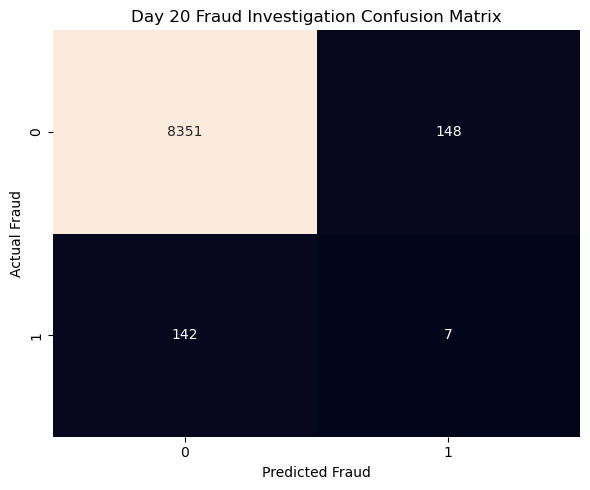

In [43]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False
)

plt.title(
    "Day 20 Fraud Investigation Confusion Matrix"
)

plt.xlabel("Predicted Fraud")
plt.ylabel("Actual Fraud")

plt.tight_layout()
plt.show()

In [44]:
risk_level_analysis = (
    investigation_df
    .groupby(RISK_LEVEL_COLUMN)
    .agg(
        transactions=(
            "validation_row",
            "count"
        ),
        actual_fraud=(
            "actual_fraud",
            "sum"
        ),
        average_risk_score=(
            RISK_COLUMN,
            "mean"
        )
    )
    .reset_index()
)

risk_level_analysis[
    "actual_fraud_rate"
] = (
    risk_level_analysis["actual_fraud"]
    /
    risk_level_analysis["transactions"]
)

display(
    risk_level_analysis
)

,risk_level,transactions,actual_fraud,average_risk_score,actual_fraud_rate
0,Critical,3,0,0.659889,0.000000
1,High,215,10,0.513542,0.046512
2,Low,4084,63,0.147199,0.015426
3,Medium,4346,76,0.359184,0.017487


In [45]:
fraud_category_analysis = (
    investigation_df
    .groupby(FRAUD_CATEGORY_COLUMN)
    .agg(
        transactions=(
            "validation_row",
            "count"
        ),
        actual_fraud=(
            "actual_fraud",
            "sum"
        ),
        average_risk_score=(
            RISK_COLUMN,
            "mean"
        )
    )
    .reset_index()
)

fraud_category_analysis[
    "actual_fraud_rate"
] = (
    fraud_category_analysis["actual_fraud"]
    /
    fraud_category_analysis["transactions"]
)

display(
    fraud_category_analysis
    .sort_values(
        "actual_fraud_rate",
        ascending=False
    )
)

,fraud_category,transactions,actual_fraud,average_risk_score,actual_fraud_rate
0,Anomaly-Driven Fraud,146,7,0.522076,0.047945
1,Normal / Low Risk,8493,142,0.258270,0.016720
2,Threshold-Detected Fraud,9,0,0.539619,0.000000


In [46]:
# Day 20 — Create investigation cases
# Use Day 18 optimized prediction

OPTIMIZED_PREDICTION_COLUMN = "optimized_prediction"
RISK_COLUMN = "hybrid_risk_score"
RISK_LEVEL_COLUMN = "risk_level"
FRAUD_CATEGORY_COLUMN = "fraud_category"
INVESTIGATION_PRIORITY_COLUMN = "investigation_priority"

investigation_cases = (
    investigation_df[
        investigation_df[OPTIMIZED_PREDICTION_COLUMN] == 1
    ]
    .copy()
)

print(
    "Transactions requiring investigation:",
    len(investigation_cases)
)

Transactions requiring investigation: 155


In [47]:
investigation_cases = (
    investigation_cases
    .sort_values(
        RISK_COLUMN,
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 highest-risk investigation cases:")

display(
    investigation_cases[
        [
            "validation_row",
            "transaction_id",
            RISK_COLUMN,
            RISK_LEVEL_COLUMN,
            FRAUD_CATEGORY_COLUMN,
            INVESTIGATION_PRIORITY_COLUMN,
            "actual_fraud"
        ]
    ].head(20)
)

Top 20 highest-risk investigation cases:


,validation_row,transaction_id,hybrid_risk_score,risk_level,fraud_category,investigation_priority,actual_fraud
0,2435,FT00006835,0.700273,Critical,Anomaly-Driven Fraud,Medium,0
1,2505,FT00013011,0.651789,Critical,Anomaly-Driven Fraud,Medium,0
2,8168,CC00009204,0.627604,Critical,Threshold-Detected Fraud,Medium,0
3,5953,CC00005369,0.600228,High,Anomaly-Driven Fraud,Medium,0
4,2409,SF00006154,0.584037,High,Anomaly-Driven Fraud,Medium,0
5,773,CC00001600,0.579522,High,Anomaly-Driven Fraud,Medium,0
6,1368,SF00011244,0.568664,High,Anomaly-Driven Fraud,Medium,0
7,5595,SF00015700,0.567429,High,Anomaly-Driven Fraud,Medium,1
8,5740,CC00011957,0.565707,High,Anomaly-Driven Fraud,Medium,0
9,2952,SF00011699,0.562509,High,Anomaly-Driven Fraud,Medium,0


In [48]:
print("=" * 70)
print("DAY 20 — INVESTIGATION CASE SUMMARY")
print("=" * 70)

print(
    "Total validation transactions:",
    len(investigation_df)
)

print(
    "Transactions requiring investigation:",
    len(investigation_cases)
)

print("\nRisk Level Distribution:")
display(
    investigation_cases[
        RISK_LEVEL_COLUMN
    ].value_counts()
)

print("\nFraud Category Distribution:")
display(
    investigation_cases[
        FRAUD_CATEGORY_COLUMN
    ].value_counts()
)

print("\nInvestigation Priority Distribution:")
display(
    investigation_cases[
        INVESTIGATION_PRIORITY_COLUMN
    ].value_counts()
)

DAY 20 — INVESTIGATION CASE SUMMARY
Total validation transactions: 8648
Transactions requiring investigation: 155

Risk Level Distribution:


risk_level
High        152
Critical      3
Name: count, dtype: int64


Fraud Category Distribution:


fraud_category
Anomaly-Driven Fraud        146
Threshold-Detected Fraud      9
Name: count, dtype: int64


Investigation Priority Distribution:


investigation_priority
Medium    155
Name: count, dtype: int64

In [49]:
print("Actual fraud among investigation cases:")

display(
    investigation_cases[
        "actual_fraud"
    ].value_counts()
)

Actual fraud among investigation cases:


actual_fraud
0    148
1      7
Name: count, dtype: int64

In [50]:
top_20_investigation_cases = (
    investigation_cases[
        [
            "validation_row",
            "transaction_id",
            "transaction_date",
            "customer_id",
            "amount",
            "merchant_category",
            "merchant_country",
            "transaction_channel",
            "device_type",
            "is_international",
            "transactions_last_24h",
            "new_device",
            "new_location",
            RISK_COLUMN,
            RISK_LEVEL_COLUMN,
            FRAUD_CATEGORY_COLUMN,
            INVESTIGATION_PRIORITY_COLUMN,
            "actual_fraud"
        ]
    ]
    .head(20)
)

display(
    top_20_investigation_cases
)

,validation_row,transaction_id,transaction_date,customer_id,amount,merchant_category,merchant_country,transaction_channel,device_type,is_international,transactions_last_24h,new_device,new_location,hybrid_risk_score,risk_level,fraud_category,investigation_priority,actual_fraud
0,2435,FT00006835,2025-11-15 17:06:58,NaN,194.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.700273,Critical,Anomaly-Driven Fraud,Medium,0
1,2505,FT00013011,2025-12-07 07:13:04,NaN,270.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.651789,Critical,Anomaly-Driven Fraud,Medium,0
2,8168,CC00009204,2025-01-04 10:37:46,C001875,222.46,grocery,australia,pos,android,1.0,1.0,NaN,NaN,0.627604,Critical,Threshold-Detected Fraud,Medium,0
3,5953,CC00005369,2025-04-04 12:00:10,C001599,2223.76,fashion,australia,pos,mac,1.0,4.0,NaN,NaN,0.600228,High,Anomaly-Driven Fraud,Medium,0
4,2409,SF00006154,2025-11-11 15:31:18,SC005323,141.48,NaN,NaN,NaN,other,NaN,NaN,1.0,0.0,0.584037,High,Anomaly-Driven Fraud,Medium,0
5,773,CC00001600,2025-03-12 12:51:04,C000851,347.18,electronics,singapore,pos,ios,0.0,12.0,NaN,NaN,0.579522,High,Anomaly-Driven Fraud,Medium,0
6,1368,SF00011244,2025-11-01 12:19:41,SC004442,553.06,NaN,NaN,NaN,windows,NaN,NaN,0.0,1.0,0.568664,High,Anomaly-Driven Fraud,Medium,0
7,5595,SF00015700,2025-07-16 20:26:00,SC002016,257.46,NaN,NaN,NaN,android,NaN,NaN,0.0,1.0,0.567429,High,Anomaly-Driven Fraud,Medium,1
8,5740,CC00011957,2025-01-30 18:48:51,C001055,73.91,utilities,singapore,mobile_app,mac,0.0,6.0,NaN,NaN,0.565707,High,Anomaly-Driven Fraud,Medium,0
9,2952,SF00011699,2025-12-16 19:00:26,SC004098,73.38,NaN,NaN,NaN,other,NaN,NaN,1.0,0.0,0.562509,High,Anomaly-Driven Fraud,Medium,0


In [51]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

y_true = investigation_df[
    "actual_fraud"
].astype(int)

y_pred = investigation_df[
    OPTIMIZED_PREDICTION_COLUMN
].astype(int)

print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9833    0.9826    0.9829      8499
           1     0.0452    0.0470    0.0461       149

    accuracy                         0.9665      8648
   macro avg     0.5142    0.5148    0.5145      8648
weighted avg     0.9671    0.9665    0.9668      8648



In [52]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[8351  148]
 [ 142    7]]


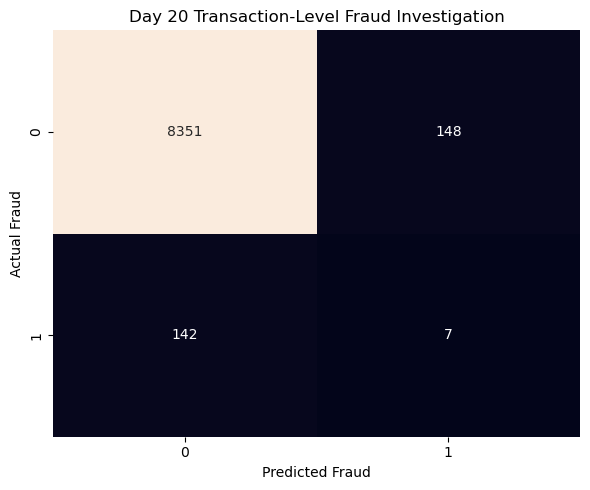

In [53]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False
)

plt.title(
    "Day 20 Transaction-Level Fraud Investigation"
)

plt.xlabel("Predicted Fraud")
plt.ylabel("Actual Fraud")

plt.tight_layout()
plt.show()

In [54]:
risk_level_analysis = (
    investigation_df
    .groupby(RISK_LEVEL_COLUMN)
    .agg(
        transactions=(
            "validation_row",
            "count"
        ),
        actual_fraud=(
            "actual_fraud",
            "sum"
        ),
        average_risk_score=(
            RISK_COLUMN,
            "mean"
        )
    )
    .reset_index()
)

risk_level_analysis[
    "actual_fraud_rate"
] = (
    risk_level_analysis["actual_fraud"]
    /
    risk_level_analysis["transactions"]
)

display(
    risk_level_analysis
)

,risk_level,transactions,actual_fraud,average_risk_score,actual_fraud_rate
0,Critical,3,0,0.659889,0.000000
1,High,215,10,0.513542,0.046512
2,Low,4084,63,0.147199,0.015426
3,Medium,4346,76,0.359184,0.017487


In [55]:
fraud_category_analysis = (
    investigation_df
    .groupby(FRAUD_CATEGORY_COLUMN)
    .agg(
        transactions=(
            "validation_row",
            "count"
        ),
        actual_fraud=(
            "actual_fraud",
            "sum"
        ),
        average_risk_score=(
            RISK_COLUMN,
            "mean"
        )
    )
    .reset_index()
)

fraud_category_analysis[
    "actual_fraud_rate"
] = (
    fraud_category_analysis["actual_fraud"]
    /
    fraud_category_analysis["transactions"]
)

display(
    fraud_category_analysis
    .sort_values(
        "actual_fraud_rate",
        ascending=False
    )
)

,fraud_category,transactions,actual_fraud,average_risk_score,actual_fraud_rate
0,Anomaly-Driven Fraud,146,7,0.522076,0.047945
1,Normal / Low Risk,8493,142,0.258270,0.016720
2,Threshold-Detected Fraud,9,0,0.539619,0.000000


In [56]:
investigation_queue = (
    investigation_cases[
        [
            "validation_row",
            "transaction_id",
            "transaction_date",
            "customer_id",
            "amount",
            RISK_COLUMN,
            RISK_LEVEL_COLUMN,
            FRAUD_CATEGORY_COLUMN,
            INVESTIGATION_PRIORITY_COLUMN,
            OPTIMIZED_PREDICTION_COLUMN,
            "actual_fraud"
        ]
    ]
    .copy()
)

investigation_queue.to_csv(
    "day20_transaction_investigation_queue.csv",
    index=False
)

print(
    "✅ Saved: day20_transaction_investigation_queue.csv"
)

✅ Saved: day20_transaction_investigation_queue.csv


In [57]:
investigation_df.to_csv(
    "day20_transaction_level_fraud_investigation.csv",
    index=False
)

print(
    "✅ Saved: day20_transaction_level_fraud_investigation.csv"
)

✅ Saved: day20_transaction_level_fraud_investigation.csv


In [58]:
print("=" * 70)
print("DAY 20 — TRANSACTION-LEVEL FRAUD INVESTIGATION")
print("=" * 70)

print(
    "Validation transactions:",
    len(validation_df)
)

print(
    "Day 18 results:",
    len(day18_df)
)

print(
    "Merged transactions:",
    len(investigation_df)
)

print(
    "Investigation cases:",
    len(investigation_cases)
)

print(
    "Actual fraud cases:",
    investigation_df["actual_fraud"].sum()
)

print("\nRisk Levels:")
display(
    investigation_df[
        RISK_LEVEL_COLUMN
    ].value_counts()
)

print("\nFraud Categories:")
display(
    investigation_df[
        FRAUD_CATEGORY_COLUMN
    ].value_counts()
)

print("\nInvestigation Priorities:")
display(
    investigation_df[
        INVESTIGATION_PRIORITY_COLUMN
    ].value_counts()
)

print(
    "\n✅ DAY 20 COMPLETED SUCCESSFULLY."
)

DAY 20 — TRANSACTION-LEVEL FRAUD INVESTIGATION
Validation transactions: 8648
Day 18 results: 8648
Merged transactions: 8648
Investigation cases: 155
Actual fraud cases: 149

Risk Levels:


risk_level
Medium      4346
Low         4084
High         215
Critical       3
Name: count, dtype: int64


Fraud Categories:


fraud_category
Normal / Low Risk           8493
Anomaly-Driven Fraud         146
Threshold-Detected Fraud       9
Name: count, dtype: int64


Investigation Priorities:


investigation_priority
Low       8493
Medium     155
Name: count, dtype: int64


✅ DAY 20 COMPLETED SUCCESSFULLY.
